In [1]:
import pandas as pd
import glob

cols = ['open_time','open','high','low','close','volume',
        'close_time','quote_volume','trades','taker_buy_base',
        'taker_buy_quote','ignore']

BASE = '/home/onyxia/work/binance-public-data/python/data/spot/monthly/klines'

def load_symbol(symbol):
    files = sorted(glob.glob(f'{BASE}/{symbol}/1h/**/*.zip', recursive=True))
    print(f"{symbol}: {len(files)} fichiers trouvés")
    dfs = [pd.read_csv(f, names=cols) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    t = pd.to_numeric(df['open_time'], errors='coerce')
    df = df[t.notna()]
    t = t[t.notna()]
    t = (t / 1000).where(t > 1e14, t)
    df['open_time'] = pd.to_datetime(t, unit='ms')

    df = df.set_index('open_time').sort_index()
    return df['close'].astype(float).rename(symbol)

btc = load_symbol('BTCUSDT')
eth = load_symbol('ETHUSDT')
sol = load_symbol('SOLUSDT')


prices = pd.concat([btc, eth, sol], axis=1).dropna().reset_index()
print(prices.shape)

BTCUSDT: 6 fichiers trouvés
ETHUSDT: 6 fichiers trouvés
SOLUSDT: 6 fichiers trouvés
(4344, 4)


In [2]:
# from Pipeline import adf_manuel,pipeline

In [3]:
# pipeline(prices)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ARCH_GARCH import *

In [5]:
prices['Δ_log_BTC'] = np.log(prices['BTCUSDT']).diff()
prices = prices.dropna(subset=['Δ_log_BTC'])

In [6]:
prices['Δ_log_BTC'].count()

np.int64(4343)

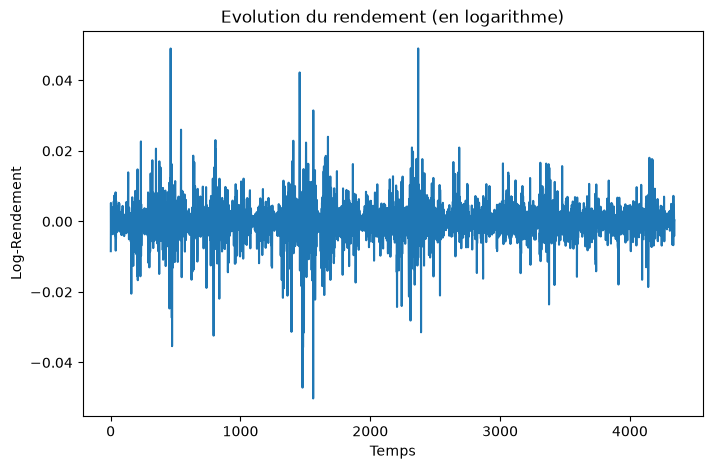

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(prices['Δ_log_BTC'])
plt.title('Evolution du rendement (en logarithme)')
plt.xlabel('Temps')
plt.ylabel('Log-Rendement')
plt.show()

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

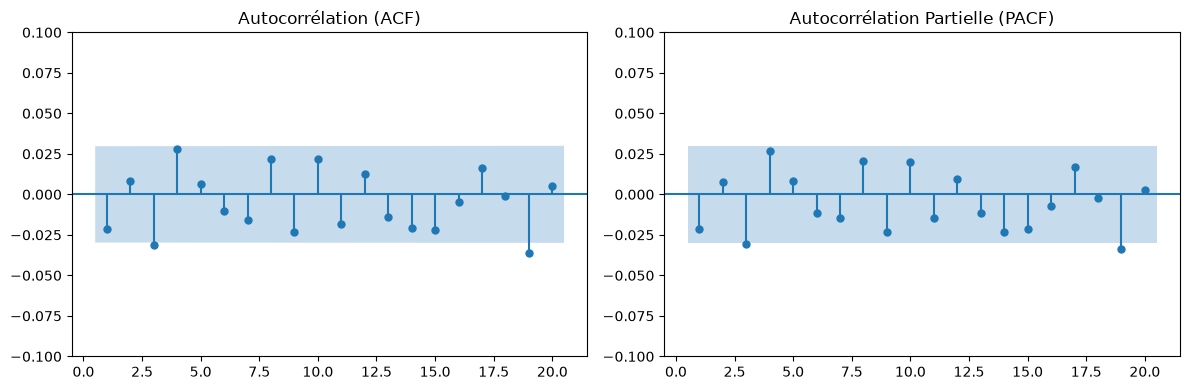

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(prices['Δ_log_BTC'], ax=axes[0], lags=20, alpha=0.05, zero=False, title="Autocorrélation (ACF)")
plot_pacf(prices['Δ_log_BTC'], ax=axes[1], lags=20, alpha=0.05, zero=False, title="Autocorrélation Partielle (PACF)")

axes[0].set_ylim(-0.1, 0.1)
axes[1].set_ylim(-0.1, 0.1)

plt.tight_layout()
plt.show()

In [10]:
valeurs_acf = acf(prices['Δ_log_BTC'], nlags=20)
valeurs_pacf = pacf(prices['Δ_log_BTC'], nlags=20)

print(valeurs_acf)
print(valeurs_pacf)

[ 1.         -0.02151323  0.00833143 -0.03121236  0.0282147   0.00648578
 -0.01025421 -0.01569953  0.0215834  -0.02349028  0.02171304 -0.01804903
  0.01262681 -0.01406917 -0.02072297 -0.02197243 -0.00497642  0.01643044
 -0.00117677 -0.03631102  0.00512205]
[ 1.         -0.02151818  0.00787589 -0.03090274  0.02689618  0.00813466
 -0.01136617 -0.01461316  0.02090955 -0.02357634  0.02017177 -0.01467029
  0.00925519 -0.01160699 -0.0230296  -0.02152556 -0.00728828  0.017005
 -0.00197656 -0.034173    0.0029801 ]


In [11]:
#Let's try to fit a AR-ARCH(1,1):
moyenne_empirique=np.mean(prices['Δ_log_BTC'])
variance_empirique=np.mean((prices['Δ_log_BTC']-moyenne_empirique)**2)

print(moyenne_empirique,variance_empirique)

2.9160466854094204e-05 2.7776143336453397e-05


In [12]:
alpha1=0.1
parametres_initiaux=[moyenne_empirique*(1-valeurs_acf[1]),valeurs_acf[1],variance_empirique*(1-alpha1),alpha1]


actif=prices['Δ_log_BTC'].to_numpy()
opti_AR_ARCH(log_vraisemblance,parametres_initiaux,actif)

Paramètres optimaux : [4.27831742e-05 7.44184706e-03 1.80153484e-05 4.38465720e-01]
Succès de la convergence : True


(np.float64(4.278317419921792e-05),
 np.float64(0.00744184706093028),
 np.float64(1.8015348404433385e-05),
 np.float64(0.4384657202408463))

AR(1)-ARCH(1) sur 4343 périodes avec comme paramètres θ= (phi0 = 4.27831742e-05, phi1 = 0.00744184706, alpha0 = 1.80153484e-05, alpha1 = 0.43846572)


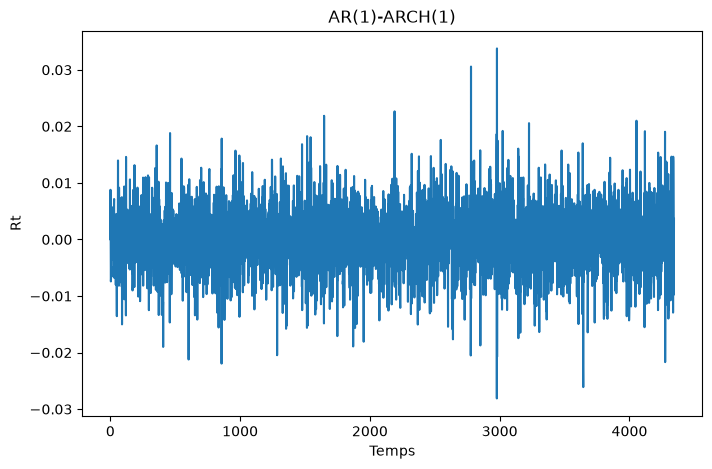

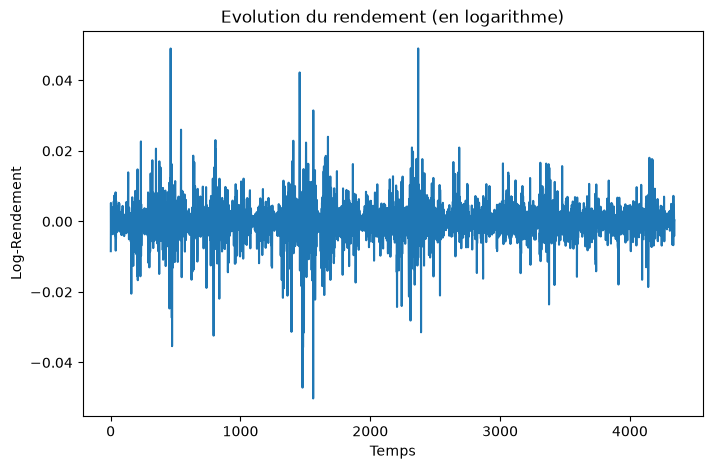

In [13]:
n=prices['Δ_log_BTC'].count()

[phi0,phi1,alpha0,alpha1]=[4.27831742e-05, 7.44184706e-03, 1.80153484e-05, 4.38465720e-01]

AR_ARCH(n,phi0,phi1,alpha0,alpha1)

plt.figure(figsize=(8, 5))
plt.plot(prices['Δ_log_BTC'])
plt.title('Evolution du rendement (en logarithme)')
plt.xlabel('Temps')
plt.ylabel('Log-Rendement')
plt.show()

In [14]:
#Let's try to fit a AR-ARCH(1,1):
moyenne_empirique=np.mean(prices['Δ_log_BTC'])
variance_empirique=np.mean((prices['Δ_log_BTC']-moyenne_empirique)**2)

print(moyenne_empirique,variance_empirique)

2.9160466854094204e-05 2.7776143336453397e-05


In [15]:
alpha1=0.1
beta0=0.95-alpha1
parametres_initiaux=[moyenne_empirique*(1-valeurs_acf[1]),valeurs_acf[1],variance_empirique*(1-alpha1),alpha1,beta0]


actif=prices['Δ_log_BTC'].to_numpy()
opti_AR_GARCH(log_vraisemblance_GARCH,parametres_initiaux,actif)

Paramètres optimaux : [ 6.52525387e-05 -3.31021518e-02  9.06991474e-07  2.13268218e-01
  7.86240606e-01]
Succès de la convergence : True


(np.float64(6.525253873664848e-05),
 np.float64(-0.03310215184429052),
 np.float64(9.0699147430818e-07),
 np.float64(0.21326821760099784),
 np.float64(0.786240606401037))

AR(1)-GARCH(1) sur 4343 périodes avec comme paramètres θ= (phi0 = 6.52525387e-05, phi1 = -0.0331021518, alpha0 = 9.06991474e-07, alpha1 = 0.213268218)


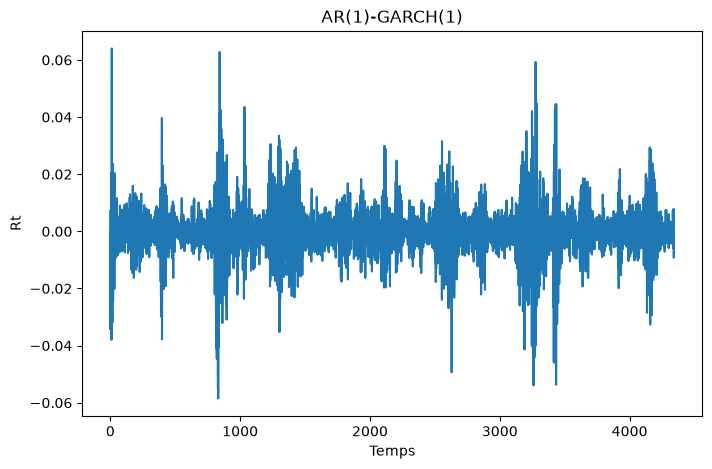

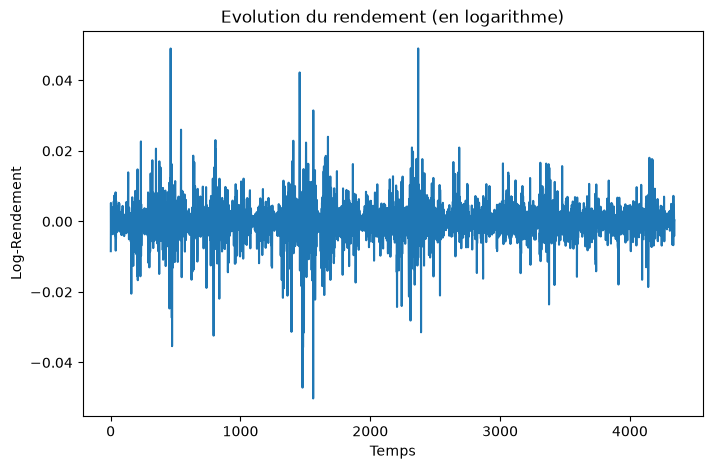

In [16]:
n=prices['Δ_log_BTC'].count()

[phi0,phi1,alpha0,alpha1,beta0]=[6.52525387e-05, -3.31021518e-02, 9.06991474e-07, 2.13268218e-01,7.86240606e-01]

AR_GARCH(n,phi0,phi1,alpha0,alpha1,beta0)

plt.figure(figsize=(8, 5))
plt.plot(prices['Δ_log_BTC'])
plt.title('Evolution du rendement (en logarithme)')
plt.xlabel('Temps')
plt.ylabel('Log-Rendement')
plt.show()

In [17]:
moyenne_empirique=np.mean(prices['Δ_log_BTC'])
variance_empirique=np.mean((prices['Δ_log_BTC']-moyenne_empirique)**2)
alpha1=0.1
beta0=0.95-alpha1
v=5

parametres_initiaux=[moyenne_empirique*(1-valeurs_acf[1]),valeurs_acf[1],variance_empirique*(1-alpha1),alpha1,beta0,v]


actif=prices['Δ_log_BTC'].to_numpy()
opti_AR_GARCH_student(log_vraisemblance_GARCH_student,parametres_initiaux,actif)

Paramètres optimaux : [ 1.44483231e-05 -4.20862530e-02  1.33274945e-06  2.27056373e-01
  7.67627689e-01  3.45444651e+00]
Succès de la convergence : True


(np.float64(1.444832314553121e-05),
 np.float64(-0.042086252995268914),
 np.float64(1.3327494537066801e-06),
 np.float64(0.22705637280074648),
 np.float64(0.7676276891047722),
 np.float64(3.45444651184936))

AR(1)-GARCH(1) with Zt suivant une loi de Student sur 4343 périodes avec comme paramètres θ= (phi0 = 1.44483231e-05, phi1 = -0.042086253, alpha0 = 1.33274945e-06, alpha1 = 0.227056373)


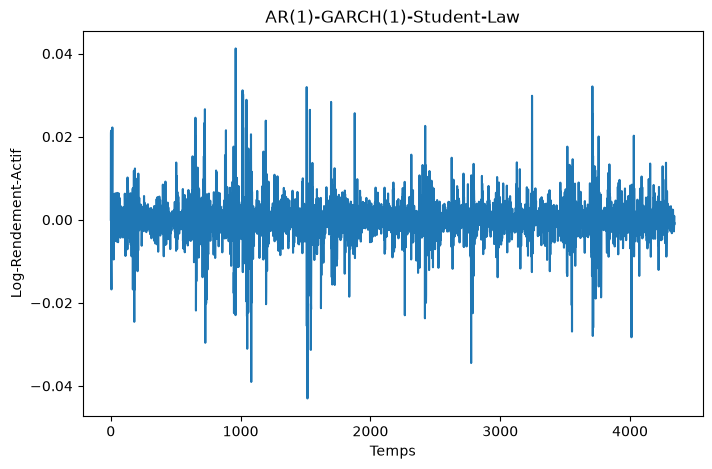

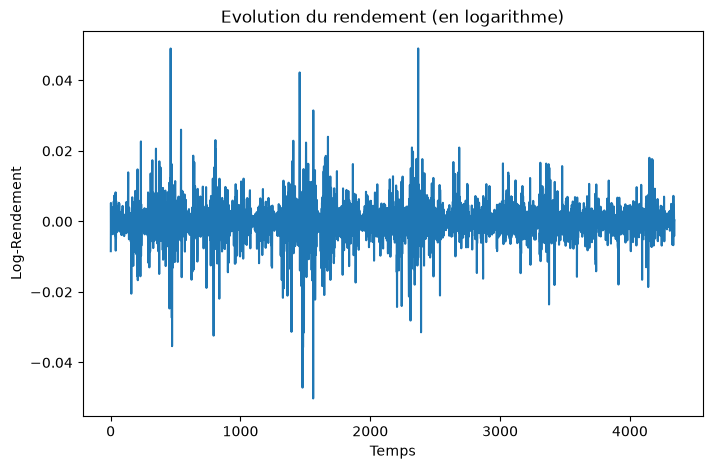

In [18]:
n=prices['Δ_log_BTC'].count()

[phi0,phi1,alpha0,alpha1,beta0,v]=[1.44483231e-05, -4.20862530e-02, 1.33274945e-06, 2.27056373e-01,7.67627689e-01, 3.45444651e+00]

AR_GARCH_student(n,phi0,phi1,alpha0,alpha1,beta0,v)

plt.figure(figsize=(8, 5))
plt.plot(prices['Δ_log_BTC'])
plt.title('Evolution du rendement (en logarithme)')
plt.xlabel('Temps')
plt.ylabel('Log-Rendement')
plt.show()

In [19]:
moyenne_emp = np.mean(actif)
variance_emp = np.var(actif)

phi1_init = valeurs_acf[1]
phi0_init = moyenne_emp * (1 - phi1_init)

alpha1_init = 0.05
y_init = 0.05 
beta0_init = 0.85

alpha0_init = variance_emp * (1 - alpha1_init - beta0_init - (y_init / 2)) #voir les relations algébrique à respecter

v_init = 5.0

parametres_initiaux = [phi0_init, phi1_init, alpha0_init, alpha1_init, beta0_init, v_init,y_init]

actif=prices['Δ_log_BTC'].to_numpy()
opti_AR_GJR_GARCH_student(log_vraisemblance_GJR_GARCH_student,parametres_initiaux,actif)

Paramètres optimaux : [ 3.22778406e-05 -4.56593195e-02  1.32843343e-06  1.83254046e-01
  7.71447280e-01  3.43619742e+00  7.90732411e-02]
Succès de la convergence : True


(np.float64(3.2277840597103334e-05),
 np.float64(-0.045659319460787134),
 np.float64(1.3284334307954361e-06),
 np.float64(0.18325404572661597),
 np.float64(0.771447279544162),
 np.float64(3.4361974174676178),
 np.float64(0.0790732410537556))

AR(1)-GJR_GARCH(1) with Zt suivant une loi de Student sur 4343 périodes avec comme paramètres θ= (phi0 = 3.22778406e-05, phi1 = -0.0456593195, alpha0 = 1.32843343e-06, alpha1 = 0.183254046)


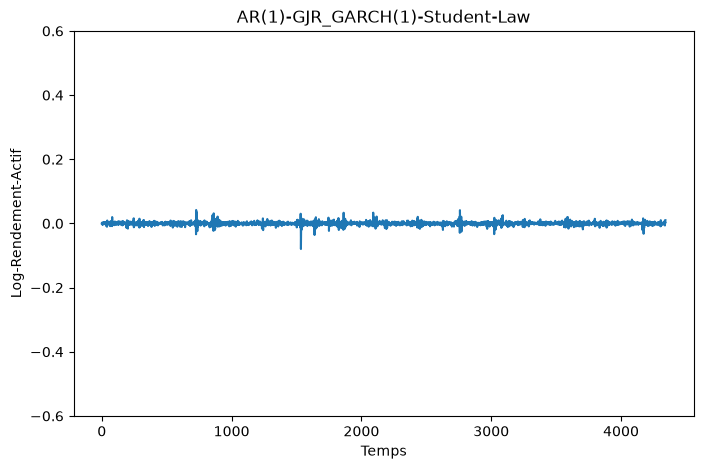

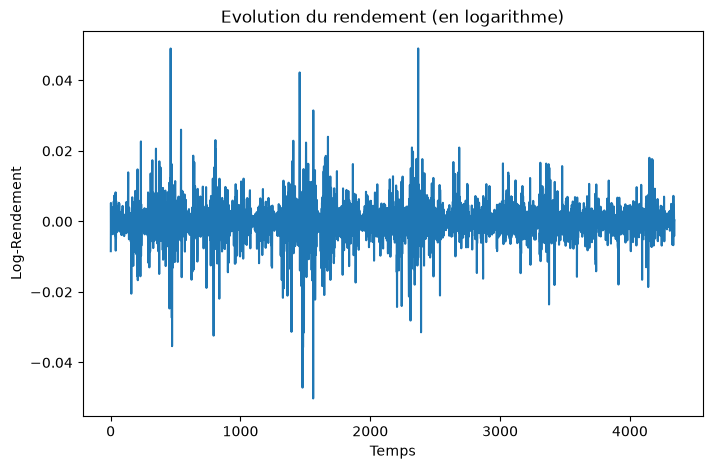

In [20]:
n=prices['Δ_log_BTC'].count()

[phi0,phi1,alpha0,alpha1,beta0,v,y]=[3.22778406e-05, -4.56593195e-02, 1.32843343e-06, 1.83254046e-01, 7.71447280e-01, 3.43619742e+00, 7.90732411e-02]

AR_GJR_GARCH_student(n,phi0,phi1,alpha0,alpha1,beta0,v,y)

plt.figure(figsize=(8, 5))
plt.plot(prices['Δ_log_BTC'])
plt.title('Evolution du rendement (en logarithme)')
plt.xlabel('Temps')
plt.ylabel('Log-Rendement')
plt.show()